2025-11-24 03:27:41.009045: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763954861.219422      48 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763954861.283368      48 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.54G [00:00<?, ?B/s]

Loading SAM 2 (Player Segmentation)...
Analyzing Play: short_game-Scene-005.mp4
00:00 | Action: Passing
00:00 | Action: Passing
00:01 | Action: Passing
00:02 | Action: Passing
00:02 | Action: Passing
00:03 | Action: Passing
00:04 | Action: Passing
00:04 | Action: Passing
00:05 | Action: Passing
00:06 | Action: Passing
00:06 | Action: Passing

FINAL ANALYSIS TABLE
| Timestamp   | Player       | Action   | Birds eye view   |
|:------------|:-------------|:---------|:-----------------|
| 00:00       | Focus Player | Passing  | [View Below]     |
| 00:00       | Focus Player | Passing  | [View Below]     |
| 00:01       | Focus Player | Passing  | [View Below]     |
| 00:02       | Focus Player | Passing  | [View Below]     |
| 00:02       | Focus Player | Passing  | [View Below]     |
| 00:03       | Focus Player | Passing  | [View Below]     |
| 00:04       | Focus Player | Passing  | [View Below]     |
| 00:04       | Focus Player | Passing  | [View Below]     |
| 00:05       | Focus Pl

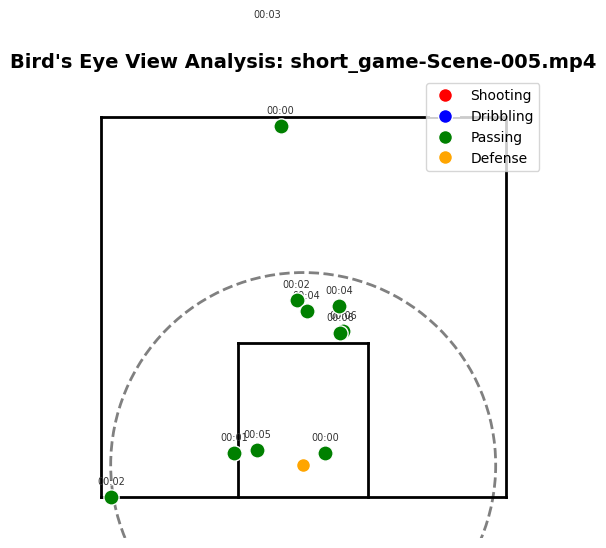

In [2]:
# @title Task 2.2: Analyzing Specific Player Actions (Final Fixed Version)
import torch
from transformers import BlipProcessor, BlipForQuestionAnswering
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Circle
import cv2
import numpy as np
from PIL import Image
from ultralytics import SAM
import pandas as pd
import glob
import os
import random

# --- 1. SETUP MODELS ---
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using Device: {device}")

print("Loading BLIP (Action Recognition)...")
processor = BlipProcessor.from_pretrained("Salesforce/blip-vqa-base")
blip_model = BlipForQuestionAnswering.from_pretrained("Salesforce/blip-vqa-base").to(device)

print("Loading SAM 2 (Player Segmentation)...")
sam_model = SAM("sam2.1_b.pt")

# --- 2. HELPER FUNCTIONS ---

def get_perspective_transform(width, height):
    """
    Creates a matrix to transform the camera view into a flat bird's eye view.
    Approximates the court as a trapezoid based on typical broadcast angles.
    """
    src = np.float32([
        [width * 0.2, height * 0.4],  # Top Left (approx key top)
        [width * 0.8, height * 0.4],  # Top Right
        [0, height],                  # Bottom Left
        [width, height]               # Bottom Right
    ])
    # Map to standard half-court dimensions (50ft x 47ft)
    dst = np.float32([
        [0, 47],   # Far Left
        [50, 47],  # Far Right
        [0, 0],    # Close Left
        [50, 0]    # Close Right
    ])
    return cv2.getPerspectiveTransform(src, dst)

def get_birdseye_pos(mask_poly, M):
    """
    Finds the player's 'feet' (bottom of mask) and maps them to the 2D court.
    """
    if len(mask_poly) == 0: return None
    # Find bottom-most point (max Y value)
    max_y_idx = np.argmax(mask_poly[:, 1])
    feet_pos = np.array([[[mask_poly[max_y_idx, 0], mask_poly[max_y_idx, 1]]]], dtype='float32')
    
    # Apply the perspective matrix
    mapped_pt = cv2.perspectiveTransform(feet_pos, M)[0][0]
    return mapped_pt

# --- 3. MAIN EXECUTION ---
# plays = glob.glob("/kaggle/working/plays/*.mp4")
plays = glob.glob("/kaggle/input/my-plays-backup/*.mp4")

if not plays:
    print("No videos found. Please ensure the 'plays' folder exists.")
else:
    selected_play = random.choice(plays)
    print(f"Analyzing Play: {os.path.basename(selected_play)}")

    cap = cv2.VideoCapture(selected_play)
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    # 1. Setup Projection Matrix
    M = get_perspective_transform(width, height)
    
    game_events = []
    
    # 2. Sampling Configuration
    # We analyze 1 frame every ~20 frames (roughly every 0.7 seconds) to speed up processing
    skip_frames = 20 
    frame_idx = 0
    
    while cap.isOpened():
        ret, frame_bgr = cap.read()
        if not ret: break
        
        # Only analyze specific frames
        if frame_idx % skip_frames == 0:
            timestamp = frame_idx / fps
            formatted_time = f"{int(timestamp // 60):02d}:{int(timestamp % 60):02d}"
            
            frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
            pil_image = Image.fromarray(frame_rgb)
            
            # --- STEP A: FIND THE PLAYER (SAM 2) ---
            results = sam_model(frame_bgr, verbose=False)[0]
            
            cx, cy = width // 2, height // 2
            best_birdseye = None
            best_bbox = None
            
            if results.masks is not None:
                min_dist = float('inf')
                
                # Iterate through all masks to find the "Focus Player" (closest to center)
                for poly in results.masks.xy:
                    if len(poly) == 0: continue
                    
                    # Calculate center of this mask
                    mask_x = np.mean(poly[:, 0])
                    mask_y = np.mean(poly[:, 1])
                    dist = ((mask_x - cx)**2 + (mask_y - cy)**2)**0.5
                    
                    if dist < min_dist:
                        min_dist = dist
                        best_birdseye = get_birdseye_pos(poly, M)
                        
                        # Calculate Bounding Box [min_x, min_y, max_x, max_y]
                        # We need this to crop the image for BLIP
                        x_coords = poly[:, 0]
                        y_coords = poly[:, 1]
                        best_bbox = (np.min(x_coords), np.min(y_coords), np.max(x_coords), np.max(y_coords))

            # --- STEP B: IDENTIFY ACTION (BLIP ON CROP) ---
            if best_bbox is not None:
                # 1. Crop the image to the player (+ padding)
                # Padding is important to capture the ball if it's slightly above/beside them
                padding = 60 
                x1 = max(0, int(best_bbox[0]) - padding)
                y1 = max(0, int(best_bbox[1]) - padding)
                x2 = min(width, int(best_bbox[2]) + padding)
                y2 = min(height, int(best_bbox[3]) + padding)
                
                cropped_player = pil_image.crop((x1, y1, x2, y2))
                
                # 2. Ask BLIP about the ZOOMED IN player
                question = "Is the person shooting, dribbling, or passing?"
                inputs = processor(cropped_player, question, return_tensors="pt").to(device)
                out = blip_model.generate(**inputs)
                action_text = processor.decode(out[0], skip_special_tokens=True).capitalize()
                
                # 3. Store Data
                game_events.append({
                    "Timestamp": formatted_time,
                    "Player": "Focus Player",
                    "Action": action_text,
                    "Court_X": best_birdseye[0],
                    "Court_Y": best_birdseye[1]
                })
                print(f"{formatted_time} | Action: {action_text}")
            else:
                # If no player found, skip or log
                pass

        frame_idx += 1

    cap.release()

    # --- 4. OUTPUT & VISUALIZATION ---
    
    if game_events:
        # A. Create DataFrame
        df = pd.DataFrame(game_events)
        
        # Display Table (Hidden Coordinates)
        display_df = df[["Timestamp", "Player", "Action"]].copy()
        display_df["Birds eye view"] = "[View Below]" 
        
        print("\n" + "="*40)
        print("FINAL ANALYSIS TABLE")
        print("="*40)
        print(display_df.to_markdown(index=False))
        
        # B. Draw Bird's Eye View
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.set_title(f"Bird's Eye View Analysis: {os.path.basename(selected_play)}", fontsize=14, fontweight='bold')
        
        # Draw Half Court Lines
        ax.plot([0, 50], [0, 0], 'k-', lw=2)      # Baseline
        ax.plot([0, 50], [47, 47], 'k-', lw=2)    # Halfcourt line
        ax.plot([0, 0], [0, 47], 'k-', lw=2)      # Left sideline
        ax.plot([50, 50], [0, 47], 'k-', lw=2)    # Right sideline
        # The Paint (Key)
        ax.plot([17, 17], [0, 19], 'k-', lw=2)
        ax.plot([33, 33], [0, 19], 'k-', lw=2)
        ax.plot([17, 33], [19, 19], 'k-', lw=2)
        # Hoop
        ax.plot([25], [4], 'o', color='orange', markersize=8)
        # 3-Point Line (Approx)
        circle = Circle((25, 4), radius=23.75, fill=False, color='gray', linestyle='--', lw=2)
        ax.add_patch(circle)
        
        ax.set_xlim(-5, 55)
        ax.set_ylim(-5, 52)
        ax.set_aspect('equal')
        ax.axis('off')
        
        # Plot Points
        # Color code based on action type
        unique_actions = df['Action'].unique()
        # Create a dynamic color map if actions vary
        colors = {"Shooting": "#FF0000", "Dribbling": "#0000FF", "Passing": "#008000", "Defense": "#FFA500"}
        
        for _, row in df.iterrows():
            # Get color, default to gray if unknown action
            action_key = [k for k in colors.keys() if k in row['Action']]
            c = colors[action_key[0]] if action_key else 'gray'
            
            ax.scatter(row['Court_X'], row['Court_Y'], s=120, c=c, edgecolors='white', zorder=5)
            # Add small timestamp label
            ax.text(row['Court_X'], row['Court_Y']+1.5, row['Timestamp'], fontsize=7, ha='center', color='#333')

        # Create Custom Legend
        from matplotlib.lines import Line2D
        legend_elements = [Line2D([0], [0], marker='o', color='w', label=k, markerfacecolor=v, markersize=10) for k, v in colors.items()]
        ax.legend(handles=legend_elements, loc='upper right')
        
        plt.show()
        
    else:
        print("No events were detected. Check if the video path is correct or if the video is empty.")

In [1]:
# Fix ALL dependencies at once:
# 1. Force NumPy < 2.0 (Fixes the binary crash)
# 2. Force Pillow < 11.0 (Fixes the '_Ink' import error)
# 3. Install the tools you need (scenedetect, ultralytics)
!pip install "numpy<2.0" "pillow<11.0" scenedetect ultralytics --upgrade --force-reinstall

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.3/112.3 kB 7.2 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 82.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 61.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.9/130.9 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.2/102.2 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 92.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━